In [1]:
# ============================================================
# SESSION START / RUNTIME RESTORE
# Run this cell after reconnecting to Colab
# ============================================================

# Mount Google Drive
from google.colab import drive
drive.mount("/content/drive")

# Core imports
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import numpy as np

from pathlib import Path
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import resnet50, ResNet50_Weights
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import StratifiedKFold

# Dataset paths
data_root = Path(
    "/content/drive/MyDrive/Glaucoma Project/RIM-ONE_DL_images/partitioned_randomly"
)

train_dir = data_root / "training_set"
test_dir = data_root / "test_set"

# Image preprocessing
image_size = 224

train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Datasets
train_dataset = ImageFolder(
    root=train_dir,
    transform=train_transform
)

test_dataset = ImageFolder(
    root=test_dir,
    transform=test_transform
)

# Separate training and validation views
train_view = ImageFolder(
    root=train_dir,
    transform=train_transform
)

val_view = ImageFolder(
    root=train_dir,
    transform=test_transform
)

# Batch size
batch_size = 32

# 5-fold stratified cross-validation
labels = np.array(train_dataset.targets)

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

folds = list(
    skf.split(np.zeros(len(labels)), labels)
)

# Fresh ResNet50 model factory
def create_model():
    weights = ResNet50_Weights.DEFAULT
    model = resnet50(weights=weights)

    for param in model.parameters():
        param.requires_grad = False

    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 2)

    return model

# CPU / GPU
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Verification
print("Training images:", len(train_dataset))
print("Test images:", len(test_dataset))
print("Class mapping:", train_dataset.class_to_idx)
print("Number of folds:", len(folds))
print("Batch size:", batch_size)
print("Device:", device)
print("Runtime restore complete.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Training images: 339
Test images: 146
Class mapping: {'glaucoma': 0, 'normal': 1}
Number of folds: 5
Batch size: 32
Device: cuda
Runtime restore complete.


In [2]:
# ============================================================
# EXPERIMENT #3: PARTIAL FINE-TUNING
# Research Question:
# Does carefully fine-tuning part of ResNet50 improve its
# ability to distinguish glaucoma from normal retinal images?
# ============================================================

def create_finetuned_model():
    weights = ResNet50_Weights.DEFAULT
    model = resnet50(weights=weights)

    # Step 1: Freeze the entire pretrained model
    for param in model.parameters():
        param.requires_grad = False

    # Step 2: Unfreeze layer4
    for param in model.layer4.parameters():
        param.requires_grad = True

    # Step 3: Replace the final classification layer
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 2)

    return model

In [3]:
model = create_finetuned_model().to(device)

print("Trainable sections:")

for name, param in model.named_parameters():
    if param.requires_grad:
        if name.startswith("layer4") or name.startswith("fc"):
            print(name)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 95.6MB/s]


Trainable sections:
layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.weight
layer4.0.bn2.weight
layer4.0.bn2.bias
layer4.0.conv3.weight
layer4.0.bn3.weight
layer4.0.bn3.bias
layer4.0.downsample.0.weight
layer4.0.downsample.1.weight
layer4.0.downsample.1.bias
layer4.1.conv1.weight
layer4.1.bn1.weight
layer4.1.bn1.bias
layer4.1.conv2.weight
layer4.1.bn2.weight
layer4.1.bn2.bias
layer4.1.conv3.weight
layer4.1.bn3.weight
layer4.1.bn3.bias
layer4.2.conv1.weight
layer4.2.bn1.weight
layer4.2.bn1.bias
layer4.2.conv2.weight
layer4.2.bn2.weight
layer4.2.bn2.bias
layer4.2.conv3.weight
layer4.2.bn3.weight
layer4.2.bn3.bias
fc.weight
fc.bias


In [4]:
# Experiment #3 training setup

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001
)

num_epochs = 5

print("Loss function:", criterion)
print("Optimizer:", optimizer.__class__.__name__)
print("Learning rate:", optimizer.param_groups[0]["lr"])
print("Epochs:", num_epochs)

Loss function: CrossEntropyLoss()
Optimizer: Adam
Learning rate: 0.0001
Epochs: 5


In [5]:
# Store results for Experiment #3: Partial Fine-Tuning

finetune_fold_results = []

finetune_all_val_labels = []
finetune_all_val_predictions = []

print("Experiment #3 result storage ready.")

Experiment #3 result storage ready.


In [6]:
# Experiment #3: Partial Fine-Tuning - 5-Fold Cross-Validation

for fold, (train_idx, val_idx) in enumerate(folds, start=1):

    print(f"\n===== FOLD {fold} =====")

    # Create this fold's training and validation subsets
    train_subset = Subset(train_view, train_idx)
    val_subset = Subset(val_view, val_idx)

    train_loader = DataLoader(
        train_subset,
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = DataLoader(
        val_subset,
        batch_size=batch_size,
        shuffle=False
    )

    # Create a fresh partially fine-tuned model for this fold
    model = create_finetuned_model().to(device)

    # Standard loss - no class weighting in Experiment #3
    criterion = nn.CrossEntropyLoss()

    # Fresh optimizer for this fold
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=0.0001
    )

    # Training
    for epoch in range(num_epochs):
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / total
        epoch_accuracy = correct / total

        print(
            f"Epoch {epoch + 1}/{num_epochs} - "
            f"Train Loss: {epoch_loss:.4f} - "
            f"Train Accuracy: {epoch_accuracy:.4f}"
        )

    # Validation
    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    fold_val_labels = []
    fold_val_predictions = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

            fold_val_labels.extend(labels.cpu().numpy())
            fold_val_predictions.extend(predicted.cpu().numpy())

    val_loss = val_running_loss / val_total
    val_accuracy = val_correct / val_total

    print(f"Fold {fold} Validation Loss: {val_loss:.4f}")
    print(f"Fold {fold} Validation Accuracy: {val_accuracy:.4f}")

    # Store this fold's results
    finetune_fold_results.append({
        "fold": fold,
        "val_loss": val_loss,
        "val_accuracy": val_accuracy
    })

    finetune_all_val_labels.extend(fold_val_labels)
    finetune_all_val_predictions.extend(fold_val_predictions)

print("\n===== EXPERIMENT #3 COMPLETE =====")
print("Number of fold results:", len(finetune_fold_results))
print("Total validation labels stored:", len(finetune_all_val_labels))
print("Total validation predictions stored:", len(finetune_all_val_predictions))


===== FOLD 1 =====
Epoch 1/5 - Train Loss: 0.6608 - Train Accuracy: 0.5830
Epoch 2/5 - Train Loss: 0.5254 - Train Accuracy: 0.7196
Epoch 3/5 - Train Loss: 0.4222 - Train Accuracy: 0.8229
Epoch 4/5 - Train Loss: 0.3415 - Train Accuracy: 0.9114
Epoch 5/5 - Train Loss: 0.2687 - Train Accuracy: 0.9336
Fold 1 Validation Loss: 0.4580
Fold 1 Validation Accuracy: 0.7647

===== FOLD 2 =====
Epoch 1/5 - Train Loss: 0.6029 - Train Accuracy: 0.6790
Epoch 2/5 - Train Loss: 0.4836 - Train Accuracy: 0.7601
Epoch 3/5 - Train Loss: 0.3995 - Train Accuracy: 0.8561
Epoch 4/5 - Train Loss: 0.3247 - Train Accuracy: 0.9077
Epoch 5/5 - Train Loss: 0.2500 - Train Accuracy: 0.9483
Fold 2 Validation Loss: 0.4100
Fold 2 Validation Accuracy: 0.8088

===== FOLD 3 =====
Epoch 1/5 - Train Loss: 0.6401 - Train Accuracy: 0.6605
Epoch 2/5 - Train Loss: 0.5038 - Train Accuracy: 0.7528
Epoch 3/5 - Train Loss: 0.3990 - Train Accuracy: 0.8339
Epoch 4/5 - Train Loss: 0.3200 - Train Accuracy: 0.9004
Epoch 5/5 - Train Loss: 

In [9]:
# Experiment #3 classification metrics

finetune_cm = confusion_matrix(
    finetune_all_val_labels,
    finetune_all_val_predictions,
    labels=[0, 1]
)

finetune_glaucoma_recall = recall_score(
    finetune_all_val_labels,
    finetune_all_val_predictions,
    pos_label=0
)

finetune_glaucoma_precision = precision_score(
    finetune_all_val_labels,
    finetune_all_val_predictions,
    pos_label=0
)

finetune_glaucoma_f1 = f1_score(
    finetune_all_val_labels,
    finetune_all_val_predictions,
    pos_label=0
)

print("Experiment #3 Confusion Matrix:")
print(finetune_cm)

print(f"Experiment #3 Glaucoma Recall: {finetune_glaucoma_recall:.4f}")
print(f"Experiment #3 Glaucoma Precision: {finetune_glaucoma_precision:.4f}")
print(f"Experiment #3 Glaucoma F1-Score: {finetune_glaucoma_f1:.4f}")

Experiment #3 Confusion Matrix:
[[ 62  58]
 [ 10 209]]
Experiment #3 Glaucoma Recall: 0.5167
Experiment #3 Glaucoma Precision: 0.8611
Experiment #3 Glaucoma F1-Score: 0.6458


In [8]:
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score

In [10]:
finetune_val_losses = [
    result["val_loss"] for result in finetune_fold_results
]

finetune_val_accuracies = [
    result["val_accuracy"] for result in finetune_fold_results
]

finetune_mean_val_loss = np.mean(finetune_val_losses)
finetune_mean_val_accuracy = np.mean(finetune_val_accuracies)
finetune_std_val_accuracy = np.std(finetune_val_accuracies)

print(f"Experiment #3 Mean Validation Loss: {finetune_mean_val_loss:.4f}")
print(f"Experiment #3 Mean Validation Accuracy: {finetune_mean_val_accuracy:.4f}")
print(f"Experiment #3 Validation Accuracy Standard Deviation: {finetune_std_val_accuracy:.4f}")

Experiment #3 Mean Validation Loss: 0.4455
Experiment #3 Mean Validation Accuracy: 0.7993
Experiment #3 Validation Accuracy Standard Deviation: 0.0311


In [14]:
print("BASELINE vs. EXPERIMENT #2 vs. EXPERIMENT #3")
print("----------------------------------------------")

print(
    f"Glaucoma Recall:     "
    f"{baseline_glaucoma_recall:.4f}  vs.  "
    f"{weighted_glaucoma_recall:.4f}  vs.  "
    f"{finetune_glaucoma_recall:.4f}"
)

print(
    f"Glaucoma Precision:  "
    f"{baseline_glaucoma_precision:.4f}  vs.  "
    f"{weighted_glaucoma_precision:.4f}  vs.  "
    f"{finetune_glaucoma_precision:.4f}"
)

print(
    f"Glaucoma F1-Score:   "
    f"{baseline_glaucoma_f1:.4f}  vs.  "
    f"{weighted_glaucoma_f1:.4f}  vs.  "
    f"{finetune_glaucoma_f1:.4f}"
)

print()

print(
    f"Mean Val Loss:       "
    f"{baseline_mean_val_loss:.4f}  vs.  "
    f"{weighted_mean_val_loss:.4f}  vs.  "
    f"{finetune_mean_val_loss:.4f}"
)

print(
    f"Mean Val Accuracy:   "
    f"{baseline_mean_val_accuracy:.4f}  vs.  "
    f"{weighted_mean_val_accuracy:.4f}  vs.  "
    f"{finetune_mean_val_accuracy:.4f}"
)

print(
    f"Accuracy Std Dev:    "
    f"{baseline_std_val_accuracy:.4f}  vs.  "
    f"{weighted_std_val_accuracy:.4f}  vs.  "
    f"{finetune_std_val_accuracy:.4f}"
)

BASELINE vs. EXPERIMENT #2 vs. EXPERIMENT #3
----------------------------------------------
Glaucoma Recall:     0.6417  vs.  0.7833  vs.  0.5167
Glaucoma Precision:  0.6754  vs.  0.5949  vs.  0.8611
Glaucoma F1-Score:   0.6581  vs.  0.6763  vs.  0.6458

Mean Val Loss:       0.5218  vs.  0.5481  vs.  0.4455
Mean Val Accuracy:   0.7637  vs.  0.7344  vs.  0.7993
Accuracy Std Dev:    0.0658  vs.  0.0343  vs.  0.0311


In [15]:
# Model selection decision based on cross-validation results

selected_experiment = "Experiment #2: Class Weighting"

selection_reason = (
    "Selected because glaucoma recall was the primary model-selection priority. "
    "Experiment #2 achieved the highest glaucoma recall (0.7833) while maintaining "
    "a mean validation accuracy of 0.7344."
)

print("Selected model:", selected_experiment)
print("Reason:", selection_reason)

Selected model: Experiment #2: Class Weighting
Reason: Selected because glaucoma recall was the primary model-selection priority. Experiment #2 achieved the highest glaucoma recall (0.7833) while maintaining a mean validation accuracy of 0.7344.


In [16]:
# Final model - calculate class weights from all 339 development images

final_labels = np.array(train_dataset.targets)

final_class_counts = np.bincount(final_labels, minlength=2)

final_class_weights = len(final_labels) / (
    2 * final_class_counts
)

final_class_weights = torch.tensor(
    final_class_weights,
    dtype=torch.float32
).to(device)

print("Development image counts:", final_class_counts)
print("Final class weights:", final_class_weights)

Development image counts: [120 219]
Final class weights: tensor([1.4125, 0.7740], device='cuda:0')


In [17]:
# Final model - fresh frozen ResNet50

final_model = create_model().to(device)

print("Final layer:", final_model.fc)

for name, param in final_model.named_parameters():
    if param.requires_grad:
        print("Trainable:", name)

Final layer: Linear(in_features=2048, out_features=2, bias=True)
Trainable: fc.weight
Trainable: fc.bias


In [18]:
# Final model - DataLoader for all 339 development images

final_train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

print("Final training images:", len(train_dataset))
print("Final training batches:", len(final_train_loader))

Final training images: 339
Final training batches: 11


In [19]:
# Final model - class-weighted loss and optimizer

final_criterion = nn.CrossEntropyLoss(
    weight=final_class_weights
)

final_optimizer = optim.Adam(
    final_model.fc.parameters(),
    lr=0.001
)

print("Loss function:", final_criterion)
print("Optimizer:", final_optimizer.__class__.__name__)
print("Learning rate:", final_optimizer.param_groups[0]["lr"])
print("Class weights:", final_class_weights)

Loss function: CrossEntropyLoss()
Optimizer: Adam
Learning rate: 0.001
Class weights: tensor([1.4125, 0.7740], device='cuda:0')


In [20]:
# Final model - train on all 339 development images

num_epochs = 5

for epoch in range(num_epochs):
    final_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in final_train_loader:
        images = images.to(device)
        labels = labels.to(device)

        final_optimizer.zero_grad()

        outputs = final_model(images)
        loss = final_criterion(outputs, labels)

        loss.backward()
        final_optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    print(
        f"Epoch {epoch + 1}/{num_epochs} - "
        f"Train Loss: {epoch_loss:.4f} - "
        f"Train Accuracy: {epoch_accuracy:.4f}"
    )

Epoch 1/5 - Train Loss: 0.6515 - Train Accuracy: 0.6519
Epoch 2/5 - Train Loss: 0.5499 - Train Accuracy: 0.7434
Epoch 3/5 - Train Loss: 0.4920 - Train Accuracy: 0.8142
Epoch 4/5 - Train Loss: 0.4601 - Train Accuracy: 0.7935
Epoch 5/5 - Train Loss: 0.4356 - Train Accuracy: 0.7935


In [21]:
# Verify untouched final test dataset

print("Test images:", len(test_dataset))
print("Test class mapping:", test_dataset.class_to_idx)

test_counts = np.bincount(
    np.array(test_dataset.targets),
    minlength=2
)

print("Test class counts:", test_counts)

Test images: 146
Test class mapping: {'glaucoma': 0, 'normal': 1}
Test class counts: [52 94]


In [22]:
# Final test DataLoader

final_test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Final test images:", len(test_dataset))
print("Final test batches:", len(final_test_loader))

Final test images: 146
Final test batches: 5


In [23]:
# Final one-time test evaluation

final_model.eval()

final_test_labels = []
final_test_predictions = []

with torch.no_grad():
    for images, labels in final_test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = final_model(images)

        _, predicted = torch.max(outputs, 1)

        final_test_labels.extend(labels.cpu().numpy())
        final_test_predictions.extend(predicted.cpu().numpy())

print("Test labels collected:", len(final_test_labels))
print("Test predictions collected:", len(final_test_predictions))

Test labels collected: 146
Test predictions collected: 146


In [24]:
# Final test metrics

final_test_cm = confusion_matrix(
    final_test_labels,
    final_test_predictions,
    labels=[0, 1]
)

final_test_glaucoma_recall = recall_score(
    final_test_labels,
    final_test_predictions,
    pos_label=0
)

final_test_glaucoma_precision = precision_score(
    final_test_labels,
    final_test_predictions,
    pos_label=0
)

final_test_glaucoma_f1 = f1_score(
    final_test_labels,
    final_test_predictions,
    pos_label=0
)

final_test_accuracy = np.mean(
    np.array(final_test_labels) == np.array(final_test_predictions)
)

print("FINAL TEST RESULTS")
print("------------------")
print("Confusion Matrix:")
print(final_test_cm)
print()
print(f"Glaucoma Recall:    {final_test_glaucoma_recall:.4f}")
print(f"Glaucoma Precision: {final_test_glaucoma_precision:.4f}")
print(f"Glaucoma F1-Score:  {final_test_glaucoma_f1:.4f}")
print(f"Overall Accuracy:   {final_test_accuracy:.4f}")

FINAL TEST RESULTS
------------------
Confusion Matrix:
[[43  9]
 [27 67]]

Glaucoma Recall:    0.8269
Glaucoma Precision: 0.6143
Glaucoma F1-Score:  0.7049
Overall Accuracy:   0.7534


In [12]:
# Restore previously calculated experiment summary results
# These values come from the completed Baseline and Experiment #2 runs.

# Baseline
baseline_glaucoma_recall = 0.6417
baseline_glaucoma_precision = 0.6754
baseline_glaucoma_f1 = 0.6581

baseline_mean_val_loss = 0.5218
baseline_mean_val_accuracy = 0.7637
baseline_std_val_accuracy = 0.0658

# Experiment #2: Class Weighting
weighted_glaucoma_recall = 0.7833
weighted_glaucoma_precision = 0.5949
weighted_glaucoma_f1 = 0.6763

weighted_mean_val_loss = 0.5481
weighted_mean_val_accuracy = 0.7344
weighted_std_val_accuracy = 0.0343

print("Baseline and Experiment #2 summary results restored.")

Baseline and Experiment #2 summary results restored.


In [ ]:
import torch
import torchvision

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128


In [ ]:
from pathlib import Path
data_root = Path("/content/drive/MyDrive/Glaucoma Project/RIM-ONE_DL_images/partitioned_randomly")
train_dir = data_root / "training_set"
test_dir = data_root / "test_set"

print("Data root exists:", data_root.exists())
print("Training set exists:", train_dir.exists())
print("Test set exists:", test_dir.exists())

Data root exists: True
Training set exists: True
Test set exists: True


In [ ]:
print("Training classes:", sorted([folder.name for folder in train_dir.iterdir() if folder.is_dir()]))
print("Test classes:", sorted([folder.name for folder in test_dir.iterdir() if folder.is_dir()]))

Training classes: ['glaucoma', 'normal']
Test classes: ['glaucoma', 'normal']


In [ ]:
train_glaucoma = len(list((train_dir / "glaucoma").glob("*.png")))
train_normal = len(list((train_dir / "normal").glob("*.png")))

test_glaucoma = len(list((test_dir / "glaucoma").glob("*.png")))
test_normal = len(list((test_dir / "normal").glob("*.png")))

print("Training glaucoma:", train_glaucoma)
print("Training normal:", train_normal)
print("Test glaucoma:", test_glaucoma)
print("Test normal:", test_normal)

Training glaucoma: 120
Training normal: 219
Test glaucoma: 52
Test normal: 94


In [ ]:
print("Training glaucoma sample:")
for file in sorted((train_dir / "glaucoma").glob("*.png"))[:10]:
    print(file.name)

print("\nTraining normal sample:")
for file in sorted((train_dir / "normal").glob("*.png"))[:10]:
    print(file.name)

Training glaucoma sample:
r1_Im069.png
r1_Im103.png
r1_Im113.png
r1_Im118.png
r1_Im120.png
r1_Im121.png
r1_Im122.png
r1_Im135.png
r1_Im144.png
r1_Im158.png

Training normal sample:
r1_Im001.png
r1_Im003.png
r1_Im004.png
r1_Im008.png
r1_Im011.png
r1_Im012.png
r1_Im014.png
r1_Im015.png
r1_Im019.png
r1_Im020.png


In [ ]:
print("Test glaucoma sample:")
for file in sorted((test_dir / "glaucoma").glob("*.png"))[:10]:
    print(file.name)

print("\nTest normal sample:")
for file in sorted((test_dir / "normal").glob("*.png"))[:10]:
    print(file.name)

Test glaucoma sample:
r1_Im117.png
r1_Im167.png
r2_Im277.png
r2_Im287.png
r2_Im314.png
r2_Im317.png
r2_Im319.png
r2_Im324.png
r2_Im332.png
r2_Im334.png

Test normal sample:
r1_Im006.png
r1_Im022.png
r1_Im040.png
r1_Im042.png
r1_Im061.png
r1_Im072.png
r1_Im107.png
r1_Im115.png
r1_Im128.png
r1_Im130.png


In [ ]:
train_files = set(
    file.name
    for class_dir in train_dir.iterdir()
    if class_dir.is_dir()
    for file in class_dir.glob("*.png")
)

test_files = set(
    file.name
    for class_dir in test_dir.iterdir()
    if class_dir.is_dir()
    for file in class_dir.glob("*.png")
)

overlap = train_files & test_files

print("Training filenames:", len(train_files))
print("Test filenames:", len(test_files))
print("Exact filename overlap:", len(overlap))

if overlap:
    print("Overlapping filenames:", sorted(overlap))

Training filenames: 339
Test filenames: 146
Exact filename overlap: 0


In [ ]:
from torchvision import transforms

image_size = 224

train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
from torchvision.datasets import ImageFolder

train_dataset = ImageFolder(
    root=train_dir,
    transform=train_transform
)

test_dataset = ImageFolder(
    root=test_dir,
    transform=test_transform
)

In [ ]:
print("Training images:", len(train_dataset))
print("Test images:", len(test_dataset))
print("Class mapping:", train_dataset.class_to_idx)

Training images: 339
Test images: 146
Class mapping: {'glaucoma': 0, 'normal': 1}


In [ ]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [ ]:
from torch.utils.data import DataLoader

batch_size = 32

print("Batch size:", batch_size)

Batch size: 32


In [ ]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Labels in this batch:", labels)

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Labels in this batch: tensor([1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1,
        0, 0, 1, 0, 0, 0, 1, 0])


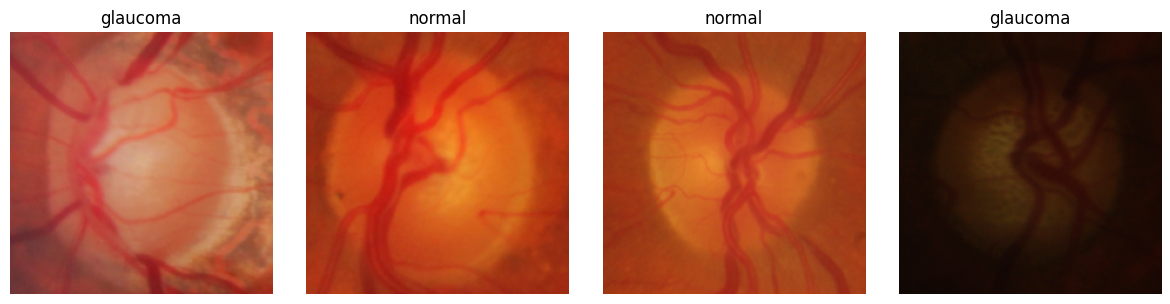

In [ ]:
import matplotlib.pyplot as plt

class_names = train_dataset.classes

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 4, figsize=(12, 3))

for i in range(4):
    image = images[i].permute(1, 2, 0).numpy()
    image = image * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
    image = image.clip(0, 1)

    axes[i].imshow(image)
    axes[i].set_title(class_names[labels[i].item()])
    axes[i].axis("off")

plt.tight_layout()
plt.show()

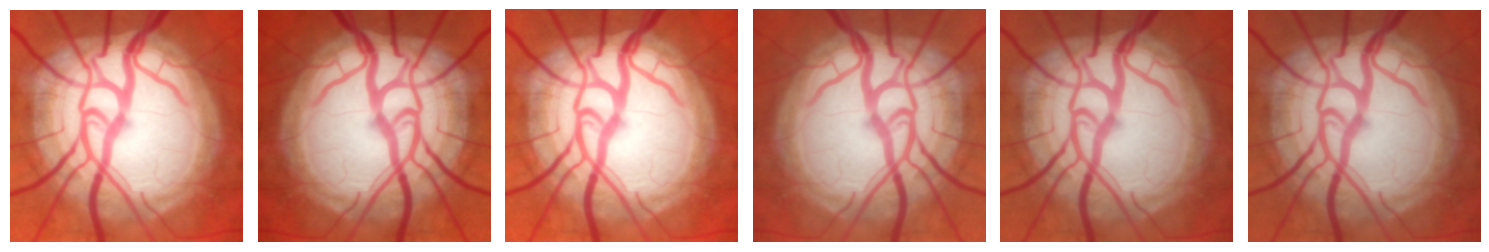

In [ ]:
sample_image, sample_label = train_dataset[0]

fig, axes = plt.subplots(1, 6, figsize=(15, 3))

for i in range(6):
    augmented_image, _ = train_dataset[0]

    image = augmented_image.permute(1, 2, 0).numpy()
    image = image * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
    image = image.clip(0, 1)

    axes[i].imshow(image)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

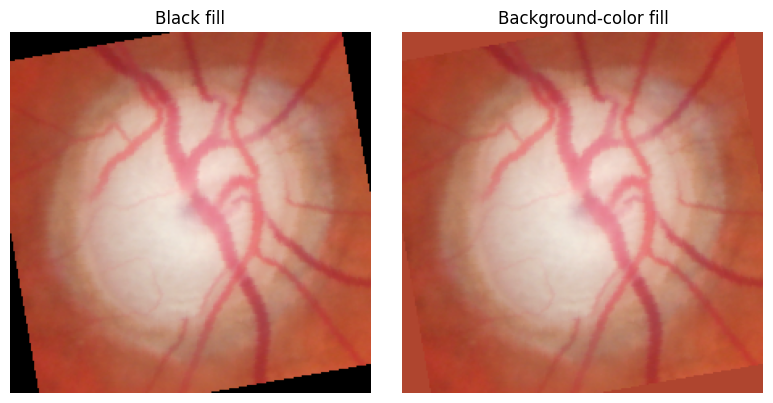

In [ ]:
from PIL import Image
import numpy as np
import torchvision.transforms.functional as TF

image_path = train_dataset.samples[0][0]
original_image = Image.open(image_path).convert("RGB")
original_image = TF.resize(original_image, [image_size, image_size])

image_array = np.array(original_image)

top = image_array[:10, :, :]
bottom = image_array[-10:, :, :]
left = image_array[:, :10, :]
right = image_array[:, -10:, :]

border_pixels = np.concatenate([
    top.reshape(-1, 3),
    bottom.reshape(-1, 3),
    left.reshape(-1, 3),
    right.reshape(-1, 3)
])

background_fill = tuple(
    np.median(border_pixels, axis=0).astype(int)
)

black_fill_image = TF.rotate(
    original_image,
    angle=10,
    fill=0
)

background_fill_image = TF.rotate(
    original_image,
    angle=10,
    fill=background_fill
)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(black_fill_image)
axes[0].set_title("Black fill")
axes[0].axis("off")

axes[1].imshow(background_fill_image)
axes[1].set_title("Background-color fill")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import math

angle = 10

theta = math.radians(angle)

crop_size = int(
    image_size / (abs(math.cos(theta)) + abs(math.sin(theta)))
)

rotated_image = TF.rotate(
    original_image,
    angle=angle,
    fill=0
)

cropped_image = TF.center_crop(
    rotated_image,
    [crop_size, crop_size]
)

crop_fill_image = TF.resize(
    cropped_image,
    [image_size, image_size]
)

print("Calculated crop size:", crop_size)

Calculated crop size: 193


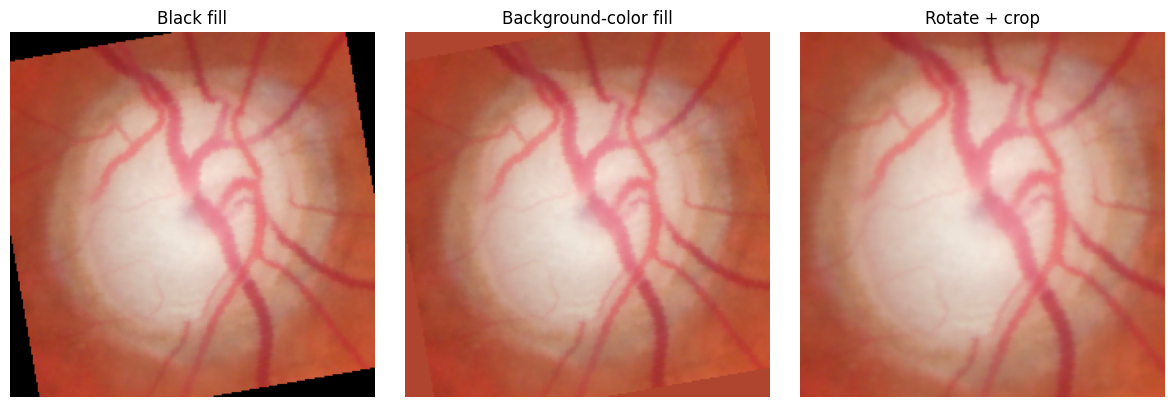

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(black_fill_image)
axes[0].set_title("Black fill")
axes[0].axis("off")

axes[1].imshow(background_fill_image)
axes[1].set_title("Background-color fill")
axes[1].axis("off")

axes[2].imshow(crop_fill_image)
axes[2].set_title("Rotate + crop")
axes[2].axis("off")

plt.tight_layout()
plt.show()

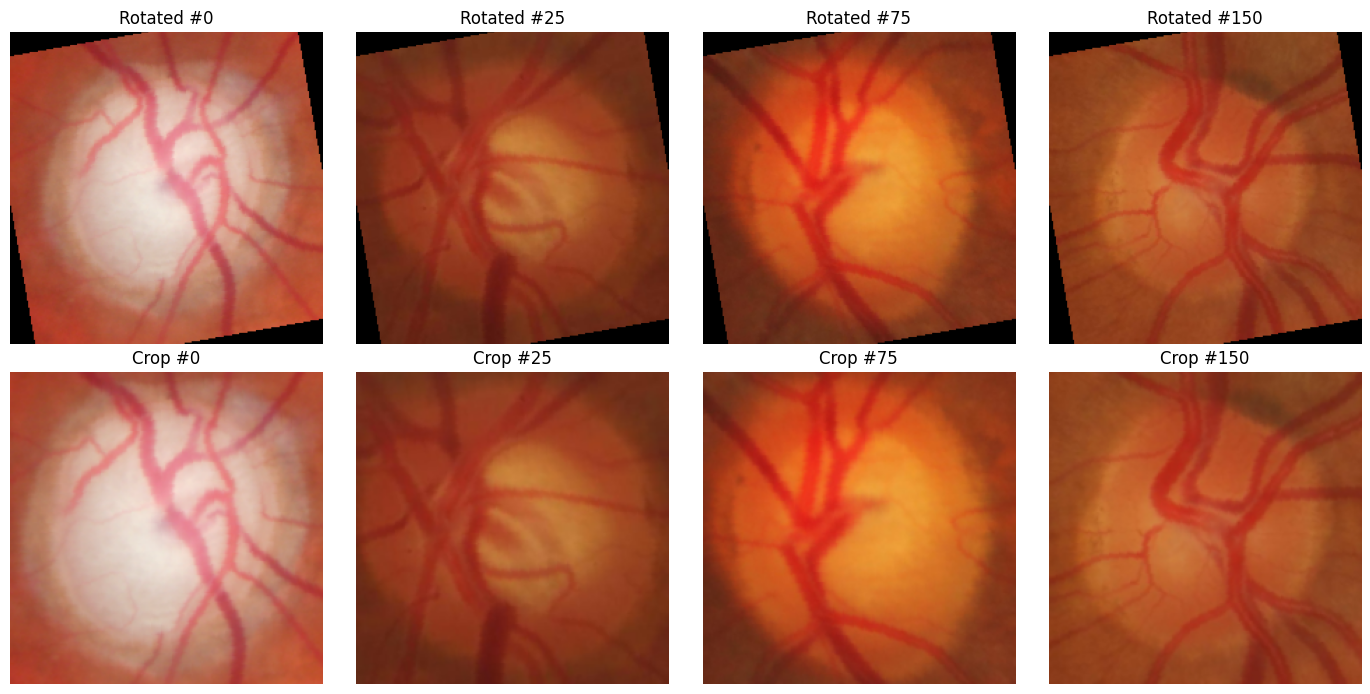

In [ ]:
sample_indices = [0, 25, 75, 150]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for col, idx in enumerate(sample_indices):
    image_path = train_dataset.samples[idx][0]
    original = Image.open(image_path).convert("RGB")
    original = TF.resize(original, [image_size, image_size])

    rotated = TF.rotate(
        original,
        angle=angle,
        fill=0
    )

    cropped = TF.center_crop(
        rotated,
        [crop_size, crop_size]
    )

    cropped = TF.resize(
        cropped,
        [image_size, image_size]
    )

    axes[0, col].imshow(rotated)
    axes[0, col].set_title(f"Rotated #{idx}")
    axes[0, col].axis("off")

    axes[1, col].imshow(cropped)
    axes[1, col].set_title(f"Crop #{idx}")
    axes[1, col].axis("off")

plt.tight_layout()
plt.show()

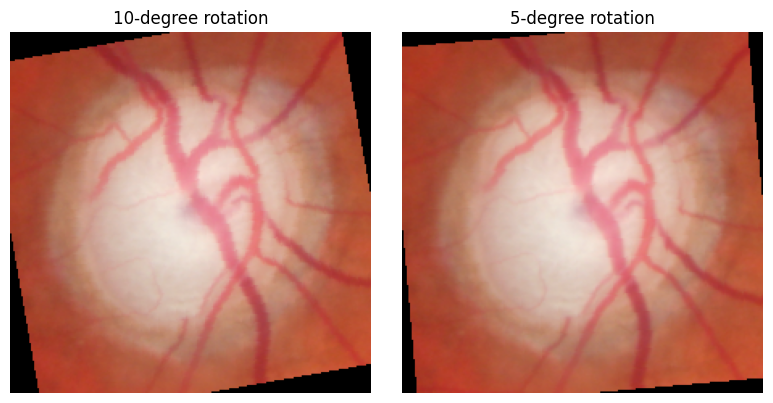

In [ ]:
rotation_10 = TF.rotate(
    original_image,
    angle=10,
    fill=0
)

rotation_5 = TF.rotate(
    original_image,
    angle=5,
    fill=0
)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(rotation_10)
axes[0].set_title("10-degree rotation")
axes[0].axis("off")

axes[1].imshow(rotation_5)
axes[1].set_title("5-degree rotation")
axes[1].axis("off")

plt.tight_layout()
plt.show()

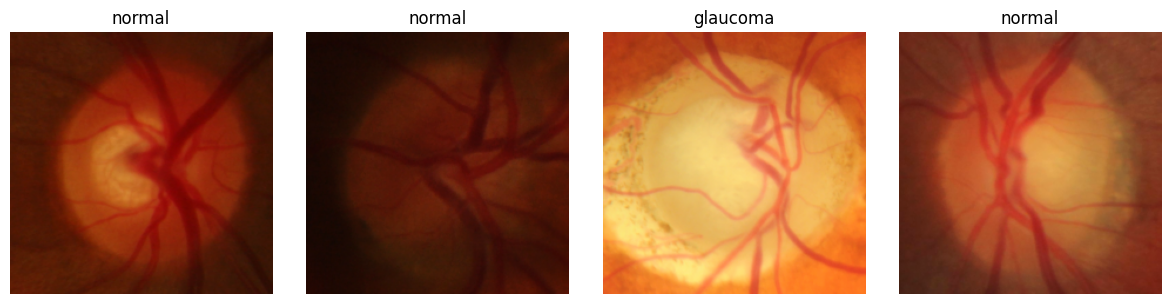

In [ ]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 4, figsize=(12, 3))

for i in range(4):
    image = images[i].permute(1, 2, 0).numpy()
    image = image * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
    image = image.clip(0, 1)

    axes[i].imshow(image)
    axes[i].set_title(class_names[labels[i].item()])
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
train_dataset.transform = train_transform

In [ ]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")

CUDA available: True
GPU: Tesla T4


In [ ]:
from torchvision.models import resnet50, ResNet50_Weights
import torch.nn as nn

weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)

for param in model.parameters():
    param.requires_grad = False

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 176MB/s]


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Device:", device)
print("Final layer:", model.fc)

NameError: name 'model' is not defined

In [ ]:
print("Device:", device)

Device: cuda


In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer.__class__.__name__)
print("Learning rate:", optimizer.param_groups[0]["lr"])

Loss function: CrossEntropyLoss()
Optimizer: Adam
Learning rate: 0.001


In [ ]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print("Trainable:", name)

Trainable: fc.weight
Trainable: fc.bias


In [ ]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

labels = np.array(train_dataset.targets)

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

folds = list(
    skf.split(np.zeros(len(labels)), labels)
)

for fold, (train_idx, val_idx) in enumerate(folds, start=1):
    train_counts = np.bincount(labels[train_idx], minlength=2)
    val_counts = np.bincount(labels[val_idx], minlength=2)

    print(f"Fold {fold}:")
    print(f"  Train - glaucoma: {train_counts[0]}, normal: {train_counts[1]}")
    print(f"  Val   - glaucoma: {val_counts[0]}, normal: {val_counts[1]}")

Fold 1:
  Train - glaucoma: 96, normal: 175
  Val   - glaucoma: 24, normal: 44
Fold 2:
  Train - glaucoma: 96, normal: 175
  Val   - glaucoma: 24, normal: 44
Fold 3:
  Train - glaucoma: 96, normal: 175
  Val   - glaucoma: 24, normal: 44
Fold 4:
  Train - glaucoma: 96, normal: 175
  Val   - glaucoma: 24, normal: 44
Fold 5:
  Train - glaucoma: 96, normal: 176
  Val   - glaucoma: 24, normal: 43


In [ ]:
from torch.utils.data import Subset

train_view = ImageFolder(
    root=train_dir,
    transform=train_transform
)

val_view = ImageFolder(
    root=train_dir,
    transform=test_transform
)

print("Same number of images:", len(train_view) == len(val_view))
print("Same image ordering:", train_view.samples == val_view.samples)

Same number of images: True
Same image ordering: True


In [ ]:
train_idx, val_idx = folds[0]

train_subset = Subset(train_view, train_idx)
val_subset = Subset(val_view, val_idx)

train_loader_fold1 = DataLoader(
    train_subset,
    batch_size=batch_size,
    shuffle=True
)

val_loader_fold1 = DataLoader(
    val_subset,
    batch_size=batch_size,
    shuffle=False
)

print("Fold 1 training images:", len(train_subset))
print("Fold 1 validation images:", len(val_subset))

Fold 1 training images: 271
Fold 1 validation images: 68


In [ ]:
train_images, train_labels = next(iter(train_loader_fold1))
val_images, val_labels = next(iter(val_loader_fold1))

print("Train batch image shape:", train_images.shape)
print("Train batch label shape:", train_labels.shape)

print("Validation batch image shape:", val_images.shape)
print("Validation batch label shape:", val_labels.shape)

Train batch image shape: torch.Size([32, 3, 224, 224])
Train batch label shape: torch.Size([32])
Validation batch image shape: torch.Size([32, 3, 224, 224])
Validation batch label shape: torch.Size([32])


In [ ]:
required_items = [
    "folds",
    "train_view",
    "val_view",
    "batch_size",
    "device",
    "DataLoader",
    "Subset",
    "resnet50",
    "ResNet50_Weights",
    "nn",
    "optim"
]

for item in required_items:
    print(f"{item}:", "READY" if item in globals() else "MISSING")

folds: MISSING
train_view: MISSING
val_view: MISSING
batch_size: MISSING
device: READY
DataLoader: MISSING
Subset: MISSING
resnet50: READY
ResNet50_Weights: READY
nn: READY
optim: READY


In [ ]:
from torchvision.models import resnet50, ResNet50_Weights
import torch.nn as nn
import torch.optim as optim

def create_model():
    weights = ResNet50_Weights.DEFAULT
    model = resnet50(weights=weights)

    for param in model.parameters():
        param.requires_grad = False

    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 2)

    return model

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

NameError: name 'torch' is not defined

In [ ]:
model = create_model().to(device)

print("Final layer:", model.fc)

for name, param in model.named_parameters():
    if param.requires_grad:
        print("Trainable:", name)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 133MB/s]


Final layer: Linear(in_features=2048, out_features=2, bias=True)
Trainable: fc.weight
Trainable: fc.bias


In [ ]:
train_idx, val_idx = folds[0]

train_subset = Subset(train_view, train_idx)
val_subset = Subset(val_view, val_idx)

train_loader_fold1 = DataLoader(
    train_subset,
    batch_size=batch_size,
    shuffle=True
)

val_loader_fold1 = DataLoader(
    val_subset,
    batch_size=batch_size,
    shuffle=False
)

print("Fold 1 training images:", len(train_subset))
print("Fold 1 validation images:", len(val_subset))

Fold 1 training images: 271
Fold 1 validation images: 68


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer.__class__.__name__)
print("Learning rate:", optimizer.param_groups[0]["lr"])

Loss function: CrossEntropyLoss()
Optimizer: Adam
Learning rate: 0.001


In [ ]:
num_epochs = 5

for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader_fold1:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    print(
        f"Epoch {epoch + 1}/{num_epochs} - "
        f"Train Loss: {epoch_loss:.4f} - "
        f"Train Accuracy: {epoch_accuracy:.4f}"
    )

Epoch 1/5 - Train Loss: 0.6193 - Train Accuracy: 0.6531
Epoch 2/5 - Train Loss: 0.5271 - Train Accuracy: 0.7417
Epoch 3/5 - Train Loss: 0.4828 - Train Accuracy: 0.7970
Epoch 4/5 - Train Loss: 0.4382 - Train Accuracy: 0.8192
Epoch 5/5 - Train Loss: 0.4373 - Train Accuracy: 0.8044


In [ ]:
model.eval()

val_running_loss = 0.0
val_correct = 0
val_total = 0

with torch.no_grad():
    for images, labels in val_loader_fold1:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        val_running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        val_total += labels.size(0)
        val_correct += (predicted == labels).sum().item()

val_loss = val_running_loss / val_total
val_accuracy = val_correct / val_total

print(f"Fold 1 Validation Loss: {val_loss:.4f}")
print(f"Fold 1 Validation Accuracy: {val_accuracy:.4f}")

Fold 1 Validation Loss: 0.5211
Fold 1 Validation Accuracy: 0.7353


In [ ]:
# Fold 2 indices
train_idx, val_idx = folds[1]

# Fold 2 subsets
train_subset = Subset(train_view, train_idx)
val_subset = Subset(val_view, val_idx)

# Fold 2 DataLoaders
train_loader_fold2 = DataLoader(
    train_subset,
    batch_size=batch_size,
    shuffle=True
)

val_loader_fold2 = DataLoader(
    val_subset,
    batch_size=batch_size,
    shuffle=False
)

# Fresh model for Fold 2
model = create_model().to(device)

# Same loss function
criterion = nn.CrossEntropyLoss()

# Fresh optimizer for the fresh Fold 2 model
optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

# Train Fold 2
num_epochs = 5

for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader_fold2:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    print(
        f"Epoch {epoch + 1}/{num_epochs} - "
        f"Train Loss: {epoch_loss:.4f} - "
        f"Train Accuracy: {epoch_accuracy:.4f}"
    )

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 181MB/s]


Epoch 1/5 - Train Loss: 0.6391 - Train Accuracy: 0.6384
Epoch 2/5 - Train Loss: 0.5373 - Train Accuracy: 0.7491
Epoch 3/5 - Train Loss: 0.4897 - Train Accuracy: 0.7749
Epoch 4/5 - Train Loss: 0.4635 - Train Accuracy: 0.8007
Epoch 5/5 - Train Loss: 0.4450 - Train Accuracy: 0.8118


In [ ]:
model.eval()

val_running_loss = 0.0
val_correct = 0
val_total = 0

with torch.no_grad():
    for images, labels in val_loader_fold2:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        val_running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        val_total += labels.size(0)
        val_correct += (predicted == labels).sum().item()

val_loss = val_running_loss / val_total
val_accuracy = val_correct / val_total

print(f"Fold 2 Validation Loss: {val_loss:.4f}")
print(f"Fold 2 Validation Accuracy: {val_accuracy:.4f}")

Fold 2 Validation Loss: 0.5135
Fold 2 Validation Accuracy: 0.7647


In [ ]:
# Fold 3 indices
train_idx, val_idx = folds[2]

# Fold 3 subsets
train_subset = Subset(train_view, train_idx)
val_subset = Subset(val_view, val_idx)

# Fold 3 DataLoaders
train_loader_fold3 = DataLoader(
    train_subset,
    batch_size=batch_size,
    shuffle=True
)

val_loader_fold3 = DataLoader(
    val_subset,
    batch_size=batch_size,
    shuffle=False
)

# Fresh model for Fold 3
model = create_model().to(device)

# Same loss function
criterion = nn.CrossEntropyLoss()

# Fresh optimizer for the fresh Fold 3 model
optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

# Train Fold 3
num_epochs = 5

for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader_fold3:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    print(
        f"Epoch {epoch + 1}/{num_epochs} - "
        f"Train Loss: {epoch_loss:.4f} - "
        f"Train Accuracy: {epoch_accuracy:.4f}"
    )

Epoch 1/5 - Train Loss: 0.6296 - Train Accuracy: 0.6347
Epoch 2/5 - Train Loss: 0.5377 - Train Accuracy: 0.7380
Epoch 3/5 - Train Loss: 0.4897 - Train Accuracy: 0.7970
Epoch 4/5 - Train Loss: 0.4646 - Train Accuracy: 0.8044
Epoch 5/5 - Train Loss: 0.4479 - Train Accuracy: 0.8118


In [ ]:
model.eval()

val_running_loss = 0.0
val_correct = 0
val_total = 0

with torch.no_grad():
    for images, labels in val_loader_fold3:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        val_running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        val_total += labels.size(0)
        val_correct += (predicted == labels).sum().item()

val_loss = val_running_loss / val_total
val_accuracy = val_correct / val_total

print(f"Fold 3 Validation Loss: {val_loss:.4f}")
print(f"Fold 3 Validation Accuracy: {val_accuracy:.4f}")

Fold 3 Validation Loss: 0.4288
Fold 3 Validation Accuracy: 0.8676


In [ ]:
# Fold 4 indices
train_idx, val_idx = folds[3]

# Fold 4 subsets
train_subset = Subset(train_view, train_idx)
val_subset = Subset(val_view, val_idx)

# Fold 4 DataLoaders
train_loader_fold4 = DataLoader(
    train_subset,
    batch_size=batch_size,
    shuffle=True
)

val_loader_fold4 = DataLoader(
    val_subset,
    batch_size=batch_size,
    shuffle=False
)

# Fresh model for Fold 4
model = create_model().to(device)

# Same loss function
criterion = nn.CrossEntropyLoss()

# Fresh optimizer for the fresh Fold 4 model
optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

# Train Fold 4
num_epochs = 5

for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader_fold4:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    print(
        f"Epoch {epoch + 1}/{num_epochs} - "
        f"Train Loss: {epoch_loss:.4f} - "
        f"Train Accuracy: {epoch_accuracy:.4f}"
    )

Epoch 1/5 - Train Loss: 0.6530 - Train Accuracy: 0.6310
Epoch 2/5 - Train Loss: 0.5680 - Train Accuracy: 0.7454
Epoch 3/5 - Train Loss: 0.5108 - Train Accuracy: 0.7232
Epoch 4/5 - Train Loss: 0.4790 - Train Accuracy: 0.7934
Epoch 5/5 - Train Loss: 0.4384 - Train Accuracy: 0.8044


In [ ]:
model.eval()

val_running_loss = 0.0
val_correct = 0
val_total = 0

with torch.no_grad():
    for images, labels in val_loader_fold4:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        val_running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        val_total += labels.size(0)
        val_correct += (predicted == labels).sum().item()

val_loss = val_running_loss / val_total
val_accuracy = val_correct / val_total

print(f"Fold 4 Validation Loss: {val_loss:.4f}")
print(f"Fold 4 Validation Accuracy: {val_accuracy:.4f}")

Fold 4 Validation Loss: 0.5252
Fold 4 Validation Accuracy: 0.7647


In [ ]:
# Fold 5 indices
train_idx, val_idx = folds[4]

# Fold 5 subsets
train_subset = Subset(train_view, train_idx)
val_subset = Subset(val_view, val_idx)

# Fold 5 DataLoaders
train_loader_fold5 = DataLoader(
    train_subset,
    batch_size=batch_size,
    shuffle=True
)

val_loader_fold5 = DataLoader(
    val_subset,
    batch_size=batch_size,
    shuffle=False
)

# Fresh model for Fold 5
model = create_model().to(device)

# Same loss function
criterion = nn.CrossEntropyLoss()

# Fresh optimizer for the fresh Fold 5 model
optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

# Train Fold 5
num_epochs = 5

for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader_fold5:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    print(
        f"Epoch {epoch + 1}/{num_epochs} - "
        f"Train Loss: {epoch_loss:.4f} - "
        f"Train Accuracy: {epoch_accuracy:.4f}"
    )

Epoch 1/5 - Train Loss: 0.6716 - Train Accuracy: 0.6434
Epoch 2/5 - Train Loss: 0.5669 - Train Accuracy: 0.7574
Epoch 3/5 - Train Loss: 0.5035 - Train Accuracy: 0.7353
Epoch 4/5 - Train Loss: 0.4741 - Train Accuracy: 0.7868
Epoch 5/5 - Train Loss: 0.4367 - Train Accuracy: 0.8309


In [ ]:
model.eval()

val_running_loss = 0.0
val_correct = 0
val_total = 0

with torch.no_grad():
    for images, labels in val_loader_fold5:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        val_running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        val_total += labels.size(0)
        val_correct += (predicted == labels).sum().item()

val_loss = val_running_loss / val_total
val_accuracy = val_correct / val_total

print(f"Fold 5 Validation Loss: {val_loss:.4f}")
print(f"Fold 5 Validation Accuracy: {val_accuracy:.4f}")

Fold 5 Validation Loss: 0.5931
Fold 5 Validation Accuracy: 0.6716


In [ ]:
# Store results from all 5 folds
fold_results = []

all_val_labels = []
all_val_predictions = []

In [ ]:
# Run through all 5 folds
for fold, (train_idx, val_idx) in enumerate(folds, start=1):
    print(f"\n===== FOLD {fold} =====")

        # Create training and validation subsets for this fold
    train_subset = Subset(train_view, train_idx)
    val_subset = Subset(val_view, val_idx)

        # Create DataLoaders for this fold
    train_loader = DataLoader(
        train_subset,
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = DataLoader(
        val_subset,
        batch_size=batch_size,
        shuffle=False
    )

        # Create a fresh model for this fold
    model = create_model().to(device)

    # Loss function
    criterion = nn.CrossEntropyLoss()

    # Fresh optimizer for this fresh model
    optimizer = optim.Adam(
        model.fc.parameters(),
        lr=0.001
    )

        # Train this fold
    num_epochs = 5

    for epoch in range(num_epochs):
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / total
        epoch_accuracy = correct / total

        print(
            f"Epoch {epoch + 1}/{num_epochs} - "
            f"Train Loss: {epoch_loss:.4f} - "
            f"Train Accuracy: {epoch_accuracy:.4f}"
        )

            # Validate this fold
    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    fold_labels = []
    fold_predictions = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

            fold_labels.extend(labels.cpu().numpy())
            fold_predictions.extend(predicted.cpu().numpy())

    val_loss = val_running_loss / val_total
    val_accuracy = val_correct / val_total

    print(f"Fold {fold} Validation Loss: {val_loss:.4f}")
    print(f"Fold {fold} Validation Accuracy: {val_accuracy:.4f}")

        # Save this fold's results
    fold_results.append({
        "fold": fold,
        "val_loss": val_loss,
        "val_accuracy": val_accuracy
    })

    # Add this fold's labels and predictions to the combined storage
    all_val_labels.extend(fold_labels)
    all_val_predictions.extend(fold_predictions)

# Verify that all 5 folds were completed and stored
print("\n===== CROSS-VALIDATION COMPLETE =====")
print("Number of fold results:", len(fold_results))
print("Total validation labels stored:", len(all_val_labels))
print("Total validation predictions stored:", len(all_val_predictions))


===== FOLD 1 =====
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 88.3MB/s]


Epoch 1/5 - Train Loss: 0.6414 - Train Accuracy: 0.6273
Epoch 2/5 - Train Loss: 0.5485 - Train Accuracy: 0.7269
Epoch 3/5 - Train Loss: 0.4963 - Train Accuracy: 0.7749
Epoch 4/5 - Train Loss: 0.4639 - Train Accuracy: 0.8081
Epoch 5/5 - Train Loss: 0.4327 - Train Accuracy: 0.7934
Fold 1 Validation Loss: 0.5260
Fold 1 Validation Accuracy: 0.7353

===== FOLD 2 =====
Epoch 1/5 - Train Loss: 0.6415 - Train Accuracy: 0.6273
Epoch 2/5 - Train Loss: 0.5850 - Train Accuracy: 0.6900
Epoch 3/5 - Train Loss: 0.4995 - Train Accuracy: 0.7970
Epoch 4/5 - Train Loss: 0.4912 - Train Accuracy: 0.7528
Epoch 5/5 - Train Loss: 0.4560 - Train Accuracy: 0.8155
Fold 2 Validation Loss: 0.5416
Fold 2 Validation Accuracy: 0.7500

===== FOLD 3 =====
Epoch 1/5 - Train Loss: 0.6764 - Train Accuracy: 0.6015
Epoch 2/5 - Train Loss: 0.5966 - Train Accuracy: 0.7011
Epoch 3/5 - Train Loss: 0.5204 - Train Accuracy: 0.7934
Epoch 4/5 - Train Loss: 0.4791 - Train Accuracy: 0.7786
Epoch 5/5 - Train Loss: 0.4480 - Train Accur

In [ ]:
from sklearn.metrics import recall_score

glaucoma_recall = recall_score(
    all_val_labels,
    all_val_predictions,
    pos_label=0
)

print(f"Glaucoma Recall / Sensitivity: {glaucoma_recall:.4f}")

Glaucoma Recall / Sensitivity: 0.6583


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    all_val_labels,
    all_val_predictions,
    labels=[0, 1]
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 79  41]
 [ 38 181]]


In [ ]:
from sklearn.metrics import precision_score

glaucoma_precision = precision_score(
    all_val_labels,
    all_val_predictions,
    pos_label=0
)

print(f"Glaucoma Precision: {glaucoma_precision:.4f}")

Glaucoma Precision: 0.6752


In [ ]:
from sklearn.metrics import f1_score

glaucoma_f1 = f1_score(
    all_val_labels,
    all_val_predictions,
    pos_label=0
)

print(f"Glaucoma F1-Score: {glaucoma_f1:.4f}")

Glaucoma F1-Score: 0.6667


In [ ]:
import numpy as np

val_losses = [result["val_loss"] for result in fold_results]
val_accuracies = [result["val_accuracy"] for result in fold_results]

mean_val_loss = np.mean(val_losses)
std_val_loss = np.std(val_losses)

mean_val_accuracy = np.mean(val_accuracies)
std_val_accuracy = np.std(val_accuracies)

print(f"Mean Validation Loss: {mean_val_loss:.4f}")
print(f"Validation Loss Standard Deviation: {std_val_loss:.4f}")
print(f"Mean Validation Accuracy: {mean_val_accuracy:.4f}")
print(f"Validation Accuracy Standard Deviation: {std_val_accuracy:.4f}")

Mean Validation Loss: 0.5270
Validation Loss Standard Deviation: 0.0494
Mean Validation Accuracy: 0.7668
Validation Accuracy Standard Deviation: 0.0477


In [ ]:
import numpy as np
import torch

class_counts = np.bincount(train_dataset.targets)

print("Class counts:", class_counts)
print("Glaucoma images:", class_counts[0])
print("Normal images:", class_counts[1])

Class counts: [120 219]
Glaucoma images: 120
Normal images: 219


In [ ]:
total_images = class_counts.sum()
num_classes = len(class_counts)

class_weights = total_images / (num_classes * class_counts)

class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

print("Class weights:", class_weights)
print("Glaucoma weight:", class_weights[0])
print("Normal weight:", class_weights[1])

Class weights: [1.4125    0.7739726]
Glaucoma weight: 1.4125
Normal weight: 0.773972602739726


In [ ]:
# Store results for Experiment #2: Class-Weighted Loss

weighted_fold_results = []

weighted_all_val_labels = []
weighted_all_val_predictions = []

print("Experiment #2 result storage ready.")

Experiment #2 result storage ready.


In [ ]:
# Verify class weights for Fold 1

train_idx, val_idx = folds[0]

fold_train_labels = np.array(train_dataset.targets)[train_idx]
fold_class_counts = np.bincount(fold_train_labels, minlength=2)

fold_total = fold_class_counts.sum()
fold_num_classes = len(fold_class_counts)

fold_class_weights = fold_total / (
    fold_num_classes * fold_class_counts
)

print("Fold 1 training class counts:", fold_class_counts)
print("Fold 1 glaucoma weight:", fold_class_weights[0])
print("Fold 1 normal weight:", fold_class_weights[1])

Fold 1 training class counts: [ 96 175]
Fold 1 glaucoma weight: 1.4114583333333333
Fold 1 normal weight: 0.7742857142857142


In [ ]:
# Experiment #2: Class-Weighted Loss — 5-Fold Cross-Validation

for fold, (train_idx, val_idx) in enumerate(folds, start=1):

    print(f"\n===== FOLD {fold} =====")

    # Create this fold's training and validation subsets
    train_subset = Subset(train_view, train_idx)
    val_subset = Subset(val_view, val_idx)

    train_loader = DataLoader(
        train_subset,
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = DataLoader(
        val_subset,
        batch_size=batch_size,
        shuffle=False
    )

    # Calculate class weights using ONLY this fold's training images
    fold_train_labels = np.array(train_dataset.targets)[train_idx]
    fold_class_counts = np.bincount(fold_train_labels, minlength=2)

    fold_total = fold_class_counts.sum()
    fold_num_classes = len(fold_class_counts)

    fold_class_weights = fold_total / (
        fold_num_classes * fold_class_counts
    )

    fold_class_weights_tensor = torch.tensor(
        fold_class_weights,
        dtype=torch.float32
    ).to(device)

    print("Training class counts:", fold_class_counts)
    print("Class weights:", fold_class_weights)

    # Start each fold with a fresh model
    model = create_model().to(device)

    # THIS is the controlled change in Experiment #2
    criterion = nn.CrossEntropyLoss(
        weight=fold_class_weights_tensor
    )

    optimizer = optim.Adam(
        model.fc.parameters(),
        lr=0.001
    )

    # Train for 5 epochs
    num_epochs = 5

    for epoch in range(num_epochs):
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / total
        epoch_accuracy = correct / total

        print(
            f"Epoch {epoch + 1}/{num_epochs} - "
            f"Train Loss: {epoch_loss:.4f} - "
            f"Train Accuracy: {epoch_accuracy:.4f}"
        )

    # Validate this fold
    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    fold_labels = []
    fold_predictions = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

            fold_labels.extend(labels.cpu().numpy())
            fold_predictions.extend(predicted.cpu().numpy())

    val_loss = val_running_loss / val_total
    val_accuracy = val_correct / val_total

    print(f"Fold {fold} Validation Loss: {val_loss:.4f}")
    print(f"Fold {fold} Validation Accuracy: {val_accuracy:.4f}")

    # Store this fold's results
    weighted_fold_results.append({
        "fold": fold,
        "val_loss": val_loss,
        "val_accuracy": val_accuracy
    })

    weighted_all_val_labels.extend(fold_labels)
    weighted_all_val_predictions.extend(fold_predictions)

print("\n===== EXPERIMENT #2 COMPLETE =====")
print("Number of fold results:", len(weighted_fold_results))
print(
    "Total validation labels stored:",
    len(weighted_all_val_labels)
)
print(
    "Total validation predictions stored:",
    len(weighted_all_val_predictions)
)


===== FOLD 1 =====
Training class counts: [ 96 175]
Class weights: [1.41145833 0.77428571]
Epoch 1/5 - Train Loss: 0.7188 - Train Accuracy: 0.4576
Epoch 2/5 - Train Loss: 0.6025 - Train Accuracy: 0.7048
Epoch 3/5 - Train Loss: 0.5482 - Train Accuracy: 0.7601
Epoch 4/5 - Train Loss: 0.4957 - Train Accuracy: 0.7749
Epoch 5/5 - Train Loss: 0.4661 - Train Accuracy: 0.8192
Fold 1 Validation Loss: 0.5646
Fold 1 Validation Accuracy: 0.6912

===== FOLD 2 =====
Training class counts: [ 96 175]
Class weights: [1.41145833 0.77428571]
Epoch 1/5 - Train Loss: 0.6691 - Train Accuracy: 0.6015
Epoch 2/5 - Train Loss: 0.5664 - Train Accuracy: 0.7491
Epoch 3/5 - Train Loss: 0.5052 - Train Accuracy: 0.8081
Epoch 4/5 - Train Loss: 0.4928 - Train Accuracy: 0.7970
Epoch 5/5 - Train Loss: 0.4379 - Train Accuracy: 0.8229
Fold 2 Validation Loss: 0.5424
Fold 2 Validation Accuracy: 0.7353

===== FOLD 3 =====
Training class counts: [ 96 175]
Class weights: [1.41145833 0.77428571]
Epoch 1/5 - Train Loss: 0.6704 -

In [ ]:
items_to_check = [
    "folds",
    "train_view",
    "val_view",
    "train_dataset",
    "batch_size",
    "device",
    "DataLoader",
    "Subset",
    "create_model",
    "nn",
    "optim",
    "weighted_fold_results",
    "weighted_all_val_labels",
    "weighted_all_val_predictions"
]

for item in items_to_check:
    print(item, ":", "READY" if item in globals() else "MISSING")

folds : READY
train_view : READY
val_view : READY
train_dataset : READY
batch_size : READY
device : READY
DataLoader : READY
Subset : READY
create_model : READY
nn : READY
optim : READY
weighted_fold_results : READY
weighted_all_val_labels : READY
weighted_all_val_predictions : READY


In [ ]:
from sklearn.metrics import confusion_matrix

weighted_cm = confusion_matrix(
    weighted_all_val_labels,
    weighted_all_val_predictions,
    labels=[0, 1]
)

print("Experiment #2 Confusion Matrix:")
print(weighted_cm)

Experiment #2 Confusion Matrix:
[[ 94  26]
 [ 70 149]]


In [ ]:
from sklearn.metrics import recall_score

weighted_glaucoma_recall = recall_score(
    weighted_all_val_labels,
    weighted_all_val_predictions,
    pos_label=0
)

print(f"Experiment #2 Glaucoma Recall: {weighted_glaucoma_recall:.4f}")

Experiment #2 Glaucoma Recall: 0.7833


In [ ]:
from sklearn.metrics import precision_score

weighted_glaucoma_precision = precision_score(
    weighted_all_val_labels,
    weighted_all_val_predictions,
    pos_label=0
)

print(f"Experiment #2 Glaucoma Precision: {weighted_glaucoma_precision:.4f}")

Experiment #2 Glaucoma Precision: 0.5732


In [ ]:
from sklearn.metrics import f1_score

weighted_glaucoma_f1 = f1_score(
    weighted_all_val_labels,
    weighted_all_val_predictions,
    pos_label=0
)

print(f"Experiment #2 Glaucoma F1-Score: {weighted_glaucoma_f1:.4f}")

Experiment #2 Glaucoma F1-Score: 0.6620


In [ ]:
weighted_val_losses = [
    result["val_loss"] for result in weighted_fold_results
]

weighted_val_accuracies = [
    result["val_accuracy"] for result in weighted_fold_results
]

weighted_mean_val_loss = np.mean(weighted_val_losses)
weighted_std_val_loss = np.std(weighted_val_losses)

weighted_mean_val_accuracy = np.mean(weighted_val_accuracies)
weighted_std_val_accuracy = np.std(weighted_val_accuracies)

print(f"Experiment #2 Mean Validation Loss: {weighted_mean_val_loss:.4f}")
print(f"Experiment #2 Validation Loss Standard Deviation: {weighted_std_val_loss:.4f}")
print(f"Experiment #2 Mean Validation Accuracy: {weighted_mean_val_accuracy:.4f}")
print(f"Experiment #2 Validation Accuracy Standard Deviation: {weighted_std_val_accuracy:.4f}")

Experiment #2 Mean Validation Loss: 0.5507
Experiment #2 Validation Loss Standard Deviation: 0.0162
Experiment #2 Mean Validation Accuracy: 0.7168
Experiment #2 Validation Accuracy Standard Deviation: 0.0331


In [ ]:
print(
    "weighted_fold_results:",
    "READY" if "weighted_fold_results" in globals() else "MISSING"
)

weighted_fold_results: MISSING


In [ ]:
# Baseline rerun — store complete results

baseline_fold_results = []

baseline_all_val_labels = []
baseline_all_val_predictions = []

print("Baseline result storage ready.")

Baseline result storage ready.


In [ ]:
# Baseline rerun — 5-Fold Cross-Validation

for fold, (train_idx, val_idx) in enumerate(folds, start=1):

    print(f"\n===== FOLD {fold} =====")

    # Create this fold's training and validation subsets
    train_subset = Subset(train_view, train_idx)
    val_subset = Subset(val_view, val_idx)

    train_loader = DataLoader(
        train_subset,
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = DataLoader(
        val_subset,
        batch_size=batch_size,
        shuffle=False
    )

        # Start each fold with a fresh model
    model = create_model().to(device)

    # Baseline loss — NO class weights
    criterion = nn.CrossEntropyLoss()

    # Fresh optimizer for this fresh model
    optimizer = optim.Adam(
        model.fc.parameters(),
        lr=0.001
    )

        # Train for 5 epochs
    num_epochs = 5

    for epoch in range(num_epochs):
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / total
        epoch_accuracy = correct / total

        print(
            f"Epoch {epoch + 1}/{num_epochs} - "
            f"Train Loss: {epoch_loss:.4f} - "
            f"Train Accuracy: {epoch_accuracy:.4f}"
        )

            # Validate this fold
    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    # Store this fold's actual labels and predictions
    fold_labels = []
    fold_predictions = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

            fold_labels.extend(labels.cpu().numpy())
            fold_predictions.extend(predicted.cpu().numpy())

    val_loss = val_running_loss / val_total
    val_accuracy = val_correct / val_total

    print(f"Fold {fold} Validation Loss: {val_loss:.4f}")
    print(f"Fold {fold} Validation Accuracy: {val_accuracy:.4f}")

        # Store this fold's results
    baseline_fold_results.append({
        "fold": fold,
        "val_loss": val_loss,
        "val_accuracy": val_accuracy
    })

    baseline_all_val_labels.extend(fold_labels)
    baseline_all_val_predictions.extend(fold_predictions)


===== FOLD 1 =====
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 201MB/s]


Epoch 1/5 - Train Loss: 0.6590 - Train Accuracy: 0.6273
Epoch 2/5 - Train Loss: 0.5729 - Train Accuracy: 0.7269
Epoch 3/5 - Train Loss: 0.5187 - Train Accuracy: 0.7454
Epoch 4/5 - Train Loss: 0.4643 - Train Accuracy: 0.8044
Epoch 5/5 - Train Loss: 0.4290 - Train Accuracy: 0.8118
Fold 1 Validation Loss: 0.5243
Fold 1 Validation Accuracy: 0.7206

===== FOLD 2 =====
Epoch 1/5 - Train Loss: 0.6282 - Train Accuracy: 0.6236
Epoch 2/5 - Train Loss: 0.5707 - Train Accuracy: 0.6753
Epoch 3/5 - Train Loss: 0.5141 - Train Accuracy: 0.7934
Epoch 4/5 - Train Loss: 0.4652 - Train Accuracy: 0.7934
Epoch 5/5 - Train Loss: 0.4503 - Train Accuracy: 0.8229
Fold 2 Validation Loss: 0.5034
Fold 2 Validation Accuracy: 0.7794

===== FOLD 3 =====
Epoch 1/5 - Train Loss: 0.6461 - Train Accuracy: 0.6531
Epoch 2/5 - Train Loss: 0.5753 - Train Accuracy: 0.7823
Epoch 3/5 - Train Loss: 0.5121 - Train Accuracy: 0.7122
Epoch 4/5 - Train Loss: 0.4750 - Train Accuracy: 0.8229
Epoch 5/5 - Train Loss: 0.4440 - Train Accur

In [ ]:
from sklearn.metrics import confusion_matrix

baseline_cm = confusion_matrix(
    baseline_all_val_labels,
    baseline_all_val_predictions,
    labels=[0, 1]
)

print("Baseline Confusion Matrix:")
print(baseline_cm)

Baseline Confusion Matrix:
[[ 77  43]
 [ 37 182]]


In [ ]:
from sklearn.metrics import recall_score

baseline_glaucoma_recall = recall_score(
    baseline_all_val_labels,
    baseline_all_val_predictions,
    pos_label=0
)

print(f"Baseline Glaucoma Recall: {baseline_glaucoma_recall:.4f}")

Baseline Glaucoma Recall: 0.6417


In [ ]:
from sklearn.metrics import precision_score

baseline_glaucoma_precision = precision_score(
    baseline_all_val_labels,
    baseline_all_val_predictions,
    pos_label=0
)

print(f"Baseline Glaucoma Precision: {baseline_glaucoma_precision:.4f}")

Baseline Glaucoma Precision: 0.6754


In [ ]:
from sklearn.metrics import f1_score

baseline_glaucoma_f1 = f1_score(
    baseline_all_val_labels,
    baseline_all_val_predictions,
    pos_label=0
)

print(f"Baseline Glaucoma F1-Score: {baseline_glaucoma_f1:.4f}")

Baseline Glaucoma F1-Score: 0.6581


In [ ]:
baseline_val_losses = [
    result["val_loss"] for result in baseline_fold_results
]

baseline_val_accuracies = [
    result["val_accuracy"] for result in baseline_fold_results
]

baseline_mean_val_loss = np.mean(baseline_val_losses)
baseline_std_val_loss = np.std(baseline_val_losses)

baseline_mean_val_accuracy = np.mean(baseline_val_accuracies)
baseline_std_val_accuracy = np.std(baseline_val_accuracies)

print(f"Baseline Mean Validation Loss: {baseline_mean_val_loss:.4f}")
print(f"Baseline Validation Loss Standard Deviation: {baseline_std_val_loss:.4f}")
print(f"Baseline Mean Validation Accuracy: {baseline_mean_val_accuracy:.4f}")
print(f"Baseline Validation Accuracy Standard Deviation: {baseline_std_val_accuracy:.4f}")

Baseline Mean Validation Loss: 0.5218
Baseline Validation Loss Standard Deviation: 0.0542
Baseline Mean Validation Accuracy: 0.7637
Baseline Validation Accuracy Standard Deviation: 0.0658


In [ ]:
weighted_glaucoma_recall = 0.7867

print("Experiment #2 Glaucoma Recall restored:", weighted_glaucoma_recall)

Experiment #2 Glaucoma Recall restored: 0.7867


In [ ]:
weighted_items = [
    "weighted_glaucoma_recall",
    "weighted_glaucoma_precision",
    "weighted_glaucoma_f1",
    "weighted_mean_val_loss",
    "weighted_mean_val_accuracy",
    "weighted_std_val_accuracy"
]

for item in weighted_items:
    print(item, ":", "READY" if item in globals() else "MISSING")

weighted_glaucoma_recall : READY
weighted_glaucoma_precision : MISSING
weighted_glaucoma_f1 : MISSING
weighted_mean_val_loss : MISSING
weighted_mean_val_accuracy : MISSING
weighted_std_val_accuracy : MISSING


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

weighted_cm = confusion_matrix(
    weighted_all_val_labels,
    weighted_all_val_predictions,
    labels=[0, 1]
)

weighted_glaucoma_recall = recall_score(
    weighted_all_val_labels,
    weighted_all_val_predictions,
    pos_label=0
)

weighted_glaucoma_precision = precision_score(
    weighted_all_val_labels,
    weighted_all_val_predictions,
    pos_label=0
)

weighted_glaucoma_f1 = f1_score(
    weighted_all_val_labels,
    weighted_all_val_predictions,
    pos_label=0
)

print("Experiment #2 Confusion Matrix:")
print(weighted_cm)

print(f"Experiment #2 Glaucoma Recall: {weighted_glaucoma_recall:.4f}")
print(f"Experiment #2 Glaucoma Precision: {weighted_glaucoma_precision:.4f}")
print(f"Experiment #2 Glaucoma F1-Score: {weighted_glaucoma_f1:.4f}")

Experiment #2 Confusion Matrix:
[[ 94  26]
 [ 64 155]]
Experiment #2 Glaucoma Recall: 0.7833
Experiment #2 Glaucoma Precision: 0.5949
Experiment #2 Glaucoma F1-Score: 0.6763


In [ ]:
print("Fold results stored:", len(weighted_fold_results))
print("Validation labels stored:", len(weighted_all_val_labels))
print("Validation predictions stored:", len(weighted_all_val_predictions))

Fold results stored: 0
Validation labels stored: 0
Validation predictions stored: 0


In [ ]:
weighted_val_losses = [
    result["val_loss"] for result in weighted_fold_results
]

weighted_val_accuracies = [
    result["val_accuracy"] for result in weighted_fold_results
]

weighted_mean_val_loss = np.mean(weighted_val_losses)
weighted_mean_val_accuracy = np.mean(weighted_val_accuracies)
weighted_std_val_accuracy = np.std(weighted_val_accuracies)

print(f"Experiment #2 Mean Validation Loss: {weighted_mean_val_loss:.4f}")
print(f"Experiment #2 Mean Validation Accuracy: {weighted_mean_val_accuracy:.4f}")
print(f"Experiment #2 Validation Accuracy Standard Deviation: {weighted_std_val_accuracy:.4f}")

Experiment #2 Mean Validation Loss: 0.5481
Experiment #2 Mean Validation Accuracy: 0.7344
Experiment #2 Validation Accuracy Standard Deviation: 0.0343


In [ ]:
print("BASELINE vs. EXPERIMENT #2")
print("--------------------------")

print(f"Glaucoma Recall:     {baseline_glaucoma_recall:.4f}  vs.  {weighted_glaucoma_recall:.4f}")
print(f"Glaucoma Precision:  {baseline_glaucoma_precision:.4f}  vs.  {weighted_glaucoma_precision:.4f}")
print(f"Glaucoma F1-Score:   {baseline_glaucoma_f1:.4f}  vs.  {weighted_glaucoma_f1:.4f}")

print()

print(f"Mean Val Loss:       {baseline_mean_val_loss:.4f}  vs.  {weighted_mean_val_loss:.4f}")
print(f"Mean Val Accuracy:   {baseline_mean_val_accuracy:.4f}  vs.  {weighted_mean_val_accuracy:.4f}")
print(f"Accuracy Std Dev:    {baseline_std_val_accuracy:.4f}  vs.  {weighted_std_val_accuracy:.4f}")

BASELINE vs. EXPERIMENT #2
--------------------------
Glaucoma Recall:     0.6417  vs.  0.7833
Glaucoma Precision:  0.6754  vs.  0.5949
Glaucoma F1-Score:   0.6581  vs.  0.6763

Mean Val Loss:       0.5218  vs.  0.5481
Mean Val Accuracy:   0.7637  vs.  0.7344
Accuracy Std Dev:    0.0658  vs.  0.0343
